In [1]:
!pip install sympy
!pip install pandas
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


# Data Loading & Matrix Representation

This notebook focuses on converting medical image data into matrix form  
and analyzing its structure using linear algebra concepts.

**Concepts covered:**
- Matrix representation  
- Rank and nullity  
- Redundancy in data  

In [2]:
DATA_DIR = "../data"

categories = [
    "chest_xray",
    "ct_scans",
    "mri_other"
]

In [3]:
def preprocess_image(path, size=(512,512)):
    
    img = cv2.imread(path)
    
    if img is None:
        print("Error loading:", path)
        return None
    
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    img_resized = cv2.resize(img_gray, size)
    
    return img_resized

## Step 1: Real-World Data

We begin with medical images such as X-rays, CT scans, and MRI scans.

**Purpose:**  
To use real-world data that can be represented mathematically.

**Outcome:**  
Image data ready for processing.

In [4]:
images = []
labels = []
filenames = []

for category in categories:
    
    folder = os.path.join(DATA_DIR, category)
    
    for file in os.listdir(folder):
        
        # skip hidden or non-image files
        if not file.lower().endswith((".png", ".jpg", ".jpeg")):
            continue
        
        path = os.path.join(folder, file)
        
        img = preprocess_image(path)
        
        images.append(img)
        labels.append(category)
        filenames.append(file)

print("Total images loaded:", len(images))

Total images loaded: 18


In [5]:
for i in range(5):
    print(filenames[i], "shape:", images[i].shape)

Chest_2.png shape: (512, 512)
Chest_3.png shape: (512, 512)
Chest_1.png shape: (512, 512)
Chest_6.png shape: (512, 512)
Chest_4.png shape: (512, 512)


## Visualization of Image Matrix

We visualize the image and its pixel structure to understand how  
image data is stored numerically.

**Insight:**  
Images are simply matrices of intensity values.

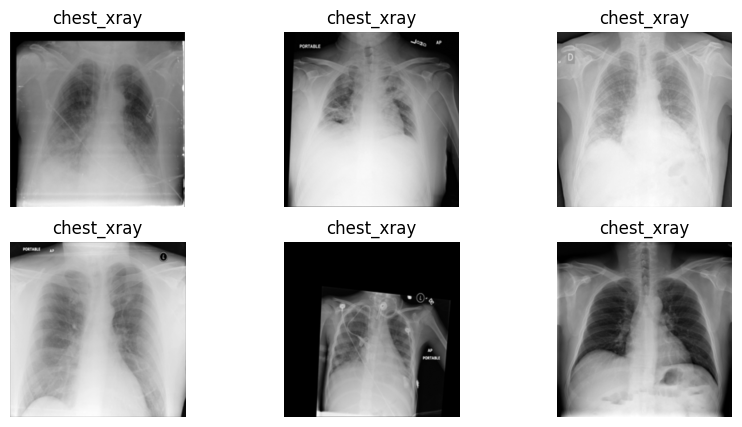

In [6]:
plt.figure(figsize=(10,5))

for i in range(6):
    
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(labels[i])
    plt.axis("off")

plt.show()

In [7]:
OUTPUT_DIR = "../output/processed_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for i in range(len(images)):
    
    name = f"{labels[i]}_{i}.png"
    
    cv2.imwrite(os.path.join(OUTPUT_DIR, name), images[i])

print("Processed images saved.")

Processed images saved.


## Step 2: Matrix Representation

Each image is converted into a matrix:

- Rows → pixel rows  
- Columns → pixel columns  
- Entries → pixel intensity values (0–255)  

**Purpose:**  
To represent image data in a mathematical form.

**Outcome:**  
A matrix suitable for linear algebra operations.

In [8]:
A = images[0]

print("Matrix representation of image:")
print("Shape:", A.shape)
print("Data type:", A.dtype)

Matrix representation of image:
Shape: (512, 512)
Data type: uint8


In [9]:
print("Total images:", len(images))
print("Matrix shape:", images[0].shape)
print("Categories:", set(labels))

Total images: 18
Matrix shape: (512, 512)
Categories: {'chest_xray', 'mri_other', 'ct_scans'}


## Step 3: Structure of the Space

We analyze the matrix to understand:

- Rank → number of independent rows/columns  
- Nullity → number of dependent components  

**Concept:** Rank and Nullity  
**Purpose:** Identify redundancy in the data  
**Outcome:** Determine if compression is possible  

In [10]:
# ============================================
# STEP 3: MATRIX SIMPLIFICATION VIA RREF
# ============================================

import numpy as np
from sympy import Matrix

print("="*60)
print("STEP 3: MATRIX SIMPLIFICATION (RREF Analysis)")
print("="*60)

# Use hero image (or first image)
hero_image = images[0]
hero_name = filenames[0]

print(f"\nAnalyzing hero image: {hero_name}")
print(f"Full image size: {hero_image.shape}")

# Analyze 50x50 submatrix (smaller for computational efficiency)
submatrix_size = 50
A_sample = hero_image[:submatrix_size, :submatrix_size].astype(float)

print(f"Submatrix for RREF analysis: {A_sample.shape}")

# Convert to SymPy Matrix for RREF
print("\nComputing Row Reduced Echelon Form...")
A_sympy = Matrix(A_sample)

# Compute RREF
# Returns: (rref_matrix, pivot_columns)
A_rref_sympy, pivot_cols = A_sympy.rref()

# Convert back to NumPy for visualization
A_rref = np.array(A_rref_sympy).astype(float)

# Analyze structure
rank = np.linalg.matrix_rank(A_sample)
nullity = A_sample.shape[1] - rank

print(f"\n--- RREF Results ---")
print(f"Rank of submatrix: {rank}")
print(f"Nullity: {nullity}")
print(f"Number of pivot columns: {len(pivot_cols)}")
print(f"Pivot column indices: {list(pivot_cols)[:10]}...")  # Show first 10

# Interpretation
print(f"\n--- Interpretation ---")
print(f"The image submatrix has rank {rank}, meaning it contains")
print(f"{rank} linearly independent rows (visual patterns).")
print(f"Nullity of {nullity} indicates {nullity} dependent/redundant patterns.")
print(f"This suggests compression potential - not all {submatrix_size} dimensions are needed!")

print("\n✓ RREF analysis complete!")

STEP 3: MATRIX SIMPLIFICATION (RREF Analysis)

Analyzing hero image: Chest_2.png
Full image size: (512, 512)
Submatrix for RREF analysis: (50, 50)

Computing Row Reduced Echelon Form...

--- RREF Results ---
Rank of submatrix: 27
Nullity: 23
Number of pivot columns: 27
Pivot column indices: [0, 3, 16, 17, 18, 19, 20, 21, 22, 23]...

--- Interpretation ---
The image submatrix has rank 27, meaning it contains
27 linearly independent rows (visual patterns).
Nullity of 23 indicates 23 dependent/redundant patterns.
This suggests compression potential - not all 50 dimensions are needed!

✓ RREF analysis complete!


## Interpretation

If the rank is less than the full dimension:

- Some rows/columns are linearly dependent  
- The image contains redundant information  

**Conclusion:**  
Redundancy exists → Compression is possible

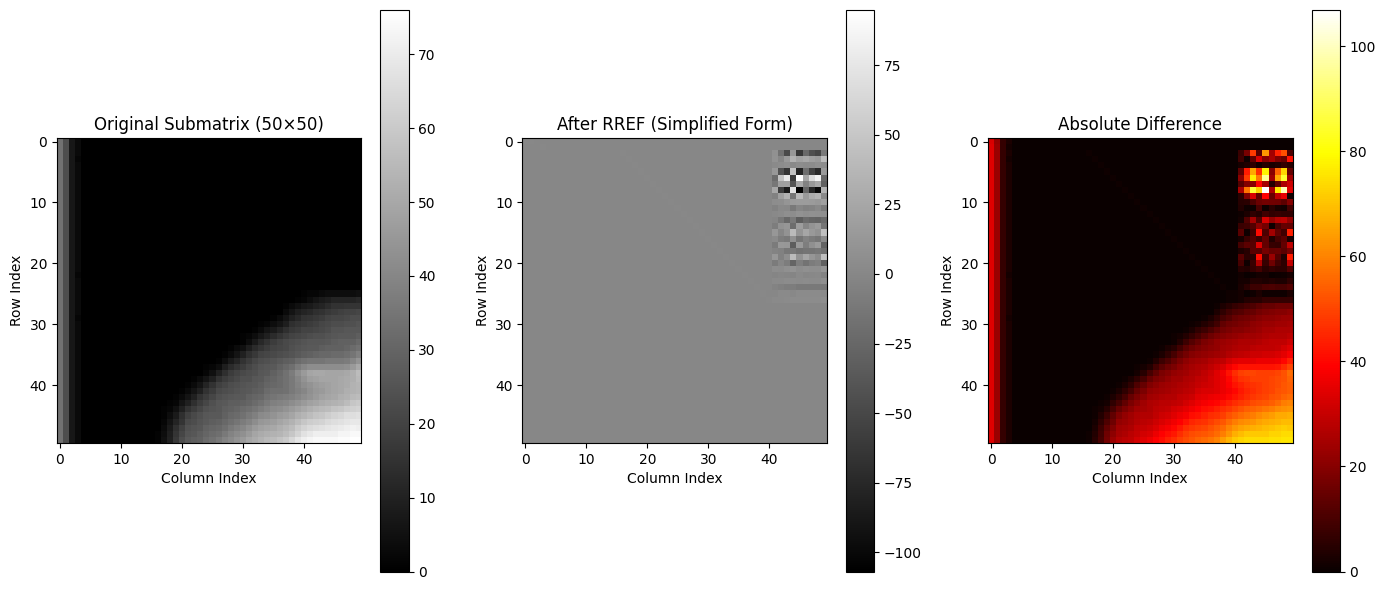

✓ RREF visualization saved to output/rref_analysis.png


In [11]:
# ============================================
# RREF VISUALIZATION
# ============================================

plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plt.imshow(A_sample, cmap='gray')
plt.title(f'Original Submatrix ({submatrix_size}×{submatrix_size})')
plt.colorbar()
plt.xlabel('Column Index')
plt.ylabel('Row Index')

plt.subplot(1, 3, 2)
plt.imshow(A_rref, cmap='gray')
plt.title('After RREF (Simplified Form)')
plt.colorbar()
plt.xlabel('Column Index')
plt.ylabel('Row Index')

plt.subplot(1, 3, 3)
difference = np.abs(A_sample - A_rref)
plt.imshow(difference, cmap='hot')
plt.title('Absolute Difference')
plt.colorbar()
plt.xlabel('Column Index')
plt.ylabel('Row Index')

plt.tight_layout()

# Save visualization
import os
os.makedirs('../output', exist_ok=True)
plt.savefig('../output/rref_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ RREF visualization saved to output/rref_analysis.png")

**Conclusion:** The presence of linear dependence indicates redundancy in the image, enabling compression.

HERO IMAGE FOR DETAILED DEMONSTRATION

Selected Image: Chest_2.png
Category: chest_xray
Shape: (512, 512)
Data type: uint8
Pixel value range: [0, 255]
Mean pixel value: 125.04
Std deviation: 56.56


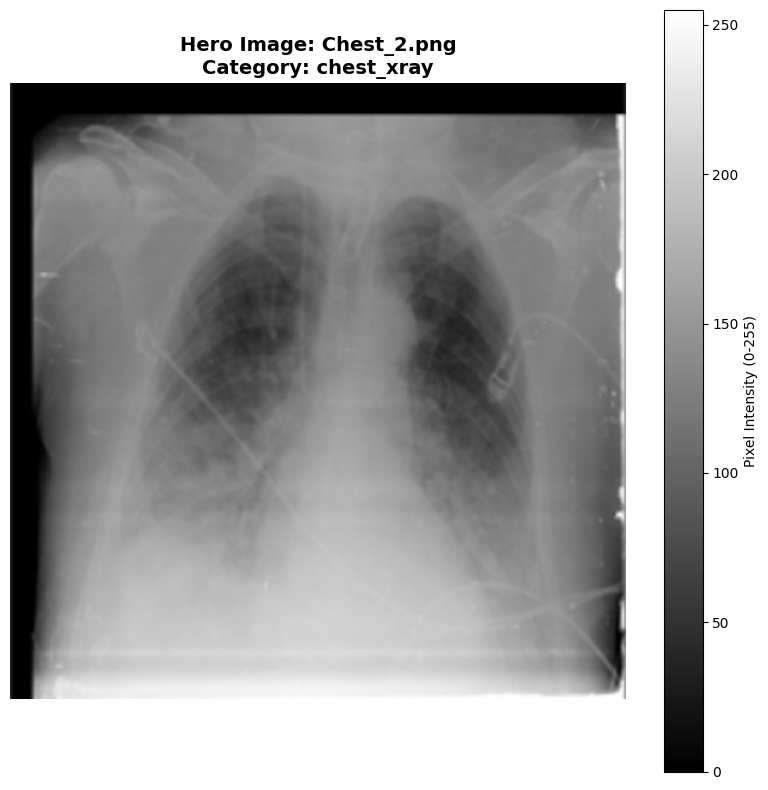


✓ Hero image selected and visualized


In [12]:
# ============================================
# HERO IMAGE SELECTION
# ============================================

print("="*60)
print("HERO IMAGE FOR DETAILED DEMONSTRATION")
print("="*60)

# Formalize hero image selection
hero_idx = 0  # Index of the chosen image
hero_image = images[hero_idx]
hero_name = filenames[hero_idx]
hero_category = labels[hero_idx]

print(f"\nSelected Image: {hero_name}")
print(f"Category: {hero_category}")
print(f"Shape: {hero_image.shape}")
print(f"Data type: {hero_image.dtype}")
print(f"Pixel value range: [{hero_image.min()}, {hero_image.max()}]")
print(f"Mean pixel value: {hero_image.mean():.2f}")
print(f"Std deviation: {hero_image.std():.2f}")

# Display hero image prominently
plt.figure(figsize=(8, 8))
plt.imshow(hero_image, cmap='gray')
plt.title(f'Hero Image: {hero_name}\nCategory: {hero_category}', 
          fontsize=14, fontweight='bold')
plt.colorbar(label='Pixel Intensity (0-255)')
plt.axis('off')
plt.tight_layout()
plt.savefig('../output/hero_image.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Hero image selected and visualized")

In [13]:
# ============================================
# IMAGE DATASET METADATA
# ============================================

import pandas as pd

print("="*60)
print("DATASET METADATA")
print("="*60)

# Create comprehensive metadata
metadata = pd.DataFrame({
    'filename': filenames,
    'category': labels,
    'width': [img.shape[1] for img in images],
    'height': [img.shape[0] for img in images],
    'min_pixel': [img.min() for img in images],
    'max_pixel': [img.max() for img in images],
    'mean_pixel': [img.mean() for img in images],
    'std_pixel': [img.std() for img in images],
    'median_pixel': [np.median(img) for img in images]
})

print("\n--- All Images ---")
print(metadata.to_string(index=False))

# Save metadata
metadata.to_csv('../output/image_metadata.csv', index=False)
print("\n✓ Metadata saved to output/image_metadata.csv")

# Summary statistics by category
print("\n" + "="*60)
print("SUMMARY BY CATEGORY")
print("="*60)
summary = metadata.groupby('category').agg({
    'filename': 'count',
    'mean_pixel': 'mean',
    'std_pixel': 'mean'
}).round(2)
summary.columns = ['Image Count', 'Avg Mean Intensity', 'Avg Std Dev']
print(summary)

print("\n--- Dataset Overview ---")
print(f"Total images: {len(images)}")
print(f"Categories: {list(set(labels))}")
print(f"Images per category: {len(images) // len(set(labels))}")
print(f"Image dimensions: {images[0].shape}")

DATASET METADATA

--- All Images ---
   filename   category  width  height  min_pixel  max_pixel  mean_pixel  std_pixel  median_pixel
Chest_2.png chest_xray    512     512          0        255  125.038486  56.564943         131.0
Chest_3.png chest_xray    512     512          0        237  131.043407  72.702091         135.0
Chest_1.png chest_xray    512     512          2        210  151.983685  39.891403         155.0
Chest_6.png chest_xray    512     512          0        230  161.955296  42.649854         172.0
Chest_4.png chest_xray    512     512          0        240   55.626549  69.346385           6.0
Chest_5.png chest_xray    512     512          0        251  111.084412  61.922747         113.0
   CT_6.jpg   ct_scans    512     512          0        255   47.073757  43.344015          19.0
   CT_4.jpg   ct_scans    512     512          0        255   61.139404  19.413052          56.0
   CT_2.jpg   ct_scans    512     512          0        228   22.476334  41.456012        

In [14]:
# ============================================
# SAVE DATA FOR PERSON 2
# ============================================

import pickle
import os

# Ensure output directory exists
os.makedirs('../output', exist_ok=True)

# Package all data for Person 2
person1_output = {
    # ===== PROCESSED IMAGES =====
    'images': images,                    # List of 18 NumPy arrays (512×512)
    'labels': labels,                    # Category names for each image
    'filenames': filenames,              # Original filenames
    
    # ===== HERO IMAGE =====
    'hero_image': hero_image,            # 512×512 NumPy array
    'hero_name': hero_name,              # Filename of hero image
    'hero_category': hero_category,      # Category
    'hero_idx': hero_idx,                # Index in images list
    
    # ===== RREF ANALYSIS RESULTS =====
    'rref_results': {
        'submatrix': A_sample,           # 50×50 original submatrix
        'rref_matrix': A_rref,           # 50×50 RREF form
        'rank': rank,                    # Rank = 27
        'nullity': nullity,              # Nullity = 23
        'pivot_cols': pivot_cols,        # Pivot column indices
        'submatrix_size': submatrix_size # Size used (50)
    },
    
    # ===== METADATA =====
    'metadata': metadata,                # DataFrame with all image stats
    'total_images': len(images),
    'image_shape': images[0].shape,
    'categories': list(set(labels)),
    'dtype': str(images[0].dtype)
}

# Save using pickle
pickle_path = '../output/person1_data.pkl'
with open(pickle_path, 'wb') as f:
    pickle.dump(person1_output, f)

file_size_mb = os.path.getsize(pickle_path) / (1024 * 1024)

print("="*60)
print("DATA PACKAGE SAVED FOR PERSON 2")
print("="*60)
print(f"\n✓ Total images: {len(images)}")
print(f"✓ Hero image: {hero_name}")
print(f"✓ RREF rank: {rank}")
print(f"✓ RREF nullity: {nullity}")
print(f"✓ Metadata rows: {len(metadata)}")
print(f"\n✓ File: {pickle_path}")
print(f"✓ Size: {file_size_mb:.2f} MB")

print("\n" + "="*60)
print("PERSON 1 DELIVERABLES COMPLETE! ✅")
print("="*60)

DATA PACKAGE SAVED FOR PERSON 2

✓ Total images: 18
✓ Hero image: Chest_2.png
✓ RREF rank: 27
✓ RREF nullity: 23
✓ Metadata rows: 18

✓ File: ../output/person1_data.pkl
✓ Size: 4.54 MB

PERSON 1 DELIVERABLES COMPLETE! ✅


In [15]:
# ============================================
# TEST: Verify Person 2 Can Load Data
# ============================================

print("="*60)
print("TESTING DATA HANDOFF")
print("="*60)

# Simulate Person 2 loading your data
print("\nSimulating Person 2's perspective...")
print("Loading person1_data.pkl...")

with open('../output/person1_data.pkl', 'rb') as f:
    test_data = pickle.load(f)

print("\n✓ File loaded successfully!")

# Verify all expected keys exist
expected_keys = ['images', 'labels', 'filenames', 'hero_image', 
                 'hero_name', 'rref_results', 'metadata']

print("\n--- Checking Data Integrity ---")
for key in expected_keys:
    if key in test_data:
        print(f"✓ {key}: Found")
    else:
        print(f"✗ {key}: MISSING!")

# Test accessing specific data
print("\n--- Accessing Data ---")
print(f"✓ Loaded {test_data['total_images']} images")
print(f"✓ Hero image: {test_data['hero_name']}")
print(f"✓ Categories: {test_data['categories']}")
print(f"✓ RREF rank: {test_data['rref_results']['rank']}")
print(f"✓ RREF nullity: {test_data['rref_results']['nullity']}")

# Test image access
test_img = test_data['images'][0]
print(f"\n✓ Sample image shape: {test_img.shape}")
print(f"✓ Sample image dtype: {test_img.dtype}")
print(f"✓ Sample image range: [{test_img.min()}, {test_img.max()}]")

# Test hero image
test_hero = test_data['hero_image']
print(f"\n✓ Hero image shape: {test_hero.shape}")
print(f"✓ Hero matches original: {np.array_equal(test_hero, hero_image)}")

print("\n" + "="*60)
print("🎉 DATA HANDOFF TEST SUCCESSFUL!")
print("="*60)
print("\nPerson 2 can successfully:")
print("  ✓ Load the pickle file")
print("  ✓ Access all images")
print("  ✓ Access hero image")
print("  ✓ Access RREF results")
print("  ✓ Begin SVD analysis")

TESTING DATA HANDOFF

Simulating Person 2's perspective...
Loading person1_data.pkl...

✓ File loaded successfully!

--- Checking Data Integrity ---
✓ images: Found
✓ labels: Found
✓ filenames: Found
✓ hero_image: Found
✓ hero_name: Found
✓ rref_results: Found
✓ metadata: Found

--- Accessing Data ---
✓ Loaded 18 images
✓ Hero image: Chest_2.png
✓ Categories: ['chest_xray', 'mri_other', 'ct_scans']
✓ RREF rank: 27
✓ RREF nullity: 23

✓ Sample image shape: (512, 512)
✓ Sample image dtype: uint8
✓ Sample image range: [0, 255]

✓ Hero image shape: (512, 512)
✓ Hero matches original: True

🎉 DATA HANDOFF TEST SUCCESSFUL!

Person 2 can successfully:
  ✓ Load the pickle file
  ✓ Access all images
  ✓ Access hero image
  ✓ Access RREF results
  ✓ Begin SVD analysis
